In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import sklearn.metrics as skm
import sklearn.model_selection as skms
import sklearn.preprocessing as skp
import random
import librosa, IPython
import librosa.display as lplt
seed = 12
np.random.seed(seed)
import tensorflow as tf
import keras as k
tf.random.set_seed(seed)

import import_ipynb
import nbimporter
from utils import trainModel,plotHistory, Grafico_Confronto_NN

I file CSV per il training e il test set sono stati creati con successo.


In [2]:
# Caricare i dati dal CSV
file_path = 'Data/features_3_sec.csv'
df = pd.read_csv(file_path)

In [3]:
# find all columns with any NA values
print("Columns with NA values are",list(df.columns[df.isnull().any()]))

Columns with NA values are []


In [4]:
# map labels to index
label_index = dict()
index_label = dict()
for i, x in enumerate(df.label.unique()):
    label_index[x] = i
    index_label[i] = x
print(label_index)
print(index_label)

{'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}
{0: 'blues', 1: 'classical', 2: 'country', 3: 'disco', 4: 'hiphop', 5: 'jazz', 6: 'metal', 7: 'pop', 8: 'reggae', 9: 'rock'}


In [5]:
# update labels in df to index
df.label = [label_index[l] for l in df.label]

In [6]:
# shuffle samples
df_shuffle = df.sample(frac=1, random_state=seed).reset_index(drop=True)

In [7]:
# remove irrelevant columns
df_shuffle.drop(['filename', 'length'], axis=1, inplace=True)
df_y = df_shuffle.pop('label')
df_X = df_shuffle

# split into train dev and test
X_train, df_test_valid_X, y_train, df_test_valid_y = skms.train_test_split(df_X, df_y, train_size=0.7, random_state=seed, stratify=df_y)
X_dev, X_test, y_dev, y_test = skms.train_test_split(df_test_valid_X, df_test_valid_y, train_size=0.66, random_state=seed, stratify=df_test_valid_y)

In [8]:
print(f"Train set has {X_train.shape[0]} records out of {len(df_shuffle)} which is {round(X_train.shape[0]/len(df_shuffle)*100)}%")
print(f"Dev set has {X_dev.shape[0]} records out of {len(df_shuffle)} which is {round(X_dev.shape[0]/len(df_shuffle)*100)}%")
print(f"Test set has {X_test.shape[0]} records out of {len(df_shuffle)} which is {round(X_test.shape[0]/len(df_shuffle)*100)}%")

Train set has 6993 records out of 9990 which is 70%
Dev set has 1978 records out of 9990 which is 20%
Test set has 1019 records out of 9990 which is 10%


In [9]:
scaler = skp.StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_dev = pd.DataFrame(scaler.transform(X_dev), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_train.columns)

In [10]:
model_1 = k.models.Sequential([
    k.layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.Dense(128, activation='relu'),
    k.layers.Dense(64, activation='relu'),
    k.layers.Dense(10, activation='softmax'),
])
print(model_1.summary())


model_1_history = trainModel(model=model_1, X_train=X_train, y_train=y_train, 
                             X_dev=X_dev, y_dev=y_dev, epochs=70, optimizer='adam')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        14,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,650 (221.29 KB)

 Trainable params: 56,650 (221.29 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/70
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3602 - loss: 1.8400 - val_accuracy: 0.6345 - val_loss: 1.0514
Epoch 2/70
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6748 - loss: 0.9476 - val_accuracy: 0.7159 - val_loss: 0.8077
Epoch 3/70
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7509 - loss: 0.7231 - val_accuracy: 0.7553 - val_loss: 0.6999
Epoch 4/70
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8007 - loss: 0.5957 - val_accuracy: 0.7846 - val_loss: 0.6306
Epoch 5/70
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8338 - loss: 0.5038 - val_accuracy: 0.8043 - val_loss: 0.5852
Epoch 6/70
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8600 - loss: 0.4313 - val_accuracy: 0.8054 - val_loss: 0.5574
Epoch 7/70
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8823 - loss: 0.3732 - val_accuracy: 0.8104 - val_loss: 0.5440
Epoch 8/70
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8957 - loss: 0.3265 - val_accuracy: 0.8190 - val_

Max. Validation Accuracy 0.8983821868896484


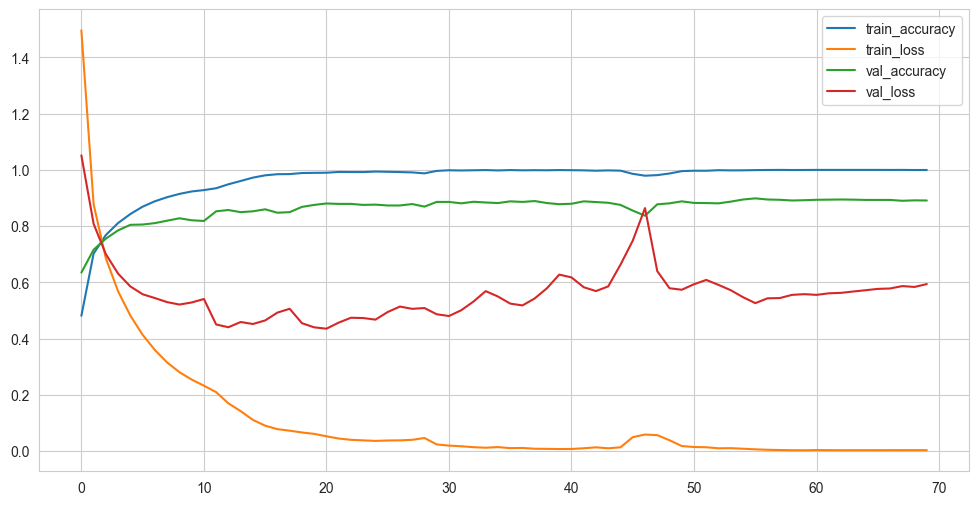

In [11]:
plotHistory(model_1_history)

In [12]:
test_loss, nn1  = model_1.evaluate(X_test, y_test, batch_size=128)
print("The test Loss is :",test_loss)
print("\nThe Best test Accuracy is :",nn1*100)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8935 - loss: 0.6027 
The test Loss is : 0.614648163318634

The Best test Accuracy is : 88.61628770828247


In [13]:
model_2 = k.models.Sequential([
    k.layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.Dropout(0.2),
    
    k.layers.Dense(256, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(128, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(64, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(10, activation='softmax'),
])
print(model_2.summary())


model_2_history = trainModel(model=model_2, X_train=X_train, y_train=y_train, 
                             X_dev=X_dev, y_dev=y_dev, epochs=100, optimizer='adam')


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,826 (792.29 KB)

 Trainable params: 202,826 (792.29 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3011 - loss: 1.9377 - val_accuracy: 0.6173 - val_loss: 1.1204
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5743 - loss: 1.2098 - val_accuracy: 0.7098 - val_loss: 0.8675
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6623 - loss: 0.9750 - val_accuracy: 0.7523 - val_loss: 0.7204
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7283 - loss: 0.8112 - val_accuracy: 0.7750 - val_loss: 0.6650
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7576 - loss: 0.7241 - val_accuracy: 0.7973 - val_loss: 0.5902
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7839 - loss: 0.6520 - val_accuracy: 0.8205 - val_loss: 0.5407
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8086 - loss: 0.5708 - val_accuracy: 0.8150 - val_loss: 0.5438
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8322 - loss: 0.5057 - val_accuracy: 0.836

Max. Validation Accuracy 0.9292214512825012


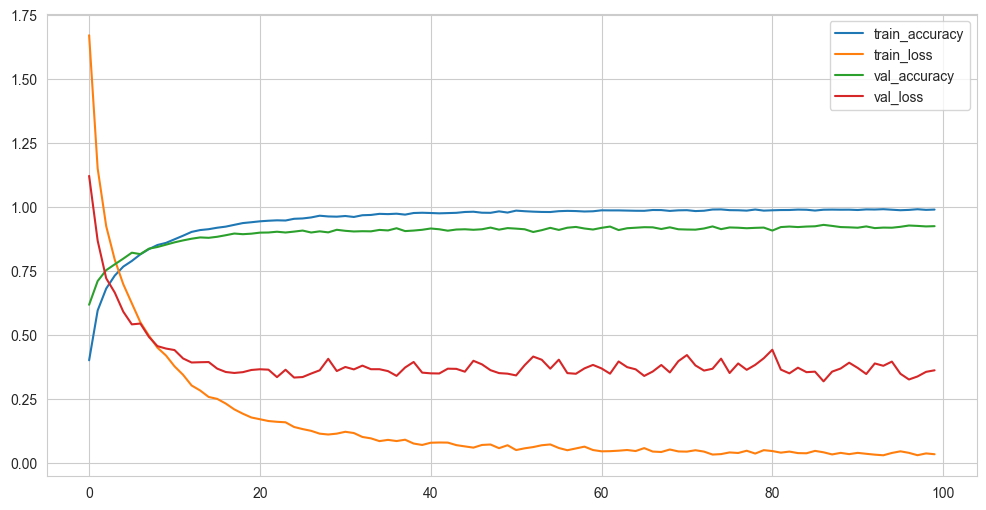

In [14]:
plotHistory(model_2_history)

In [15]:
test_loss, nn2  = model_2.evaluate(X_test, y_test, batch_size=128)
print("The test Loss is :",test_loss)
print("\nThe Best test Accuracy is :",nn2*100)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9068 - loss: 0.4290
The test Loss is : 0.4154502749443054

The Best test Accuracy is : 91.06967449188232


In [16]:
model_3 = k.models.Sequential([
    k.layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.Dropout(0.2),
    
    k.layers.Dense(256, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(128, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(64, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(10, activation='softmax'),
])
print(model_3.summary())
model_3_history = trainModel(model=model_3, X_train=X_train, y_train=y_train, 
                             X_dev=X_dev, y_dev=y_dev, epochs=700, optimizer='sgd')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 512)            │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,826 (792.29 KB)

 Trainable params: 202,826 (792.29 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/700
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1082 - loss: 2.3275 - val_accuracy: 0.1997 - val_loss: 2.2493
Epoch 2/700
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1661 - loss: 2.2571 - val_accuracy: 0.3514 - val_loss: 2.1767
Epoch 3/700
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2408 - loss: 2.1913 - val_accuracy: 0.3928 - val_loss: 2.0706
Epoch 4/700
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3101 - loss: 2.0835 - val_accuracy: 0.3862 - val_loss: 1.9126
Epoch 5/700
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3400 - loss: 1.9461 - val_accuracy: 0.3913 - val_loss: 1.7563
Epoch 6/700
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3577 - loss: 1.8238 - val_accuracy: 0.4216 - val_loss: 1.6359
Epoch 7/700
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3872 - loss: 1.7253 - val_accuracy: 0.4580 - val_loss: 1.5439
Epoch 8/700
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4155 - loss: 1.6650 - val_accuracy: 0.484

KeyboardInterrupt: 

Max. Validation Accuracy 0.9226491451263428


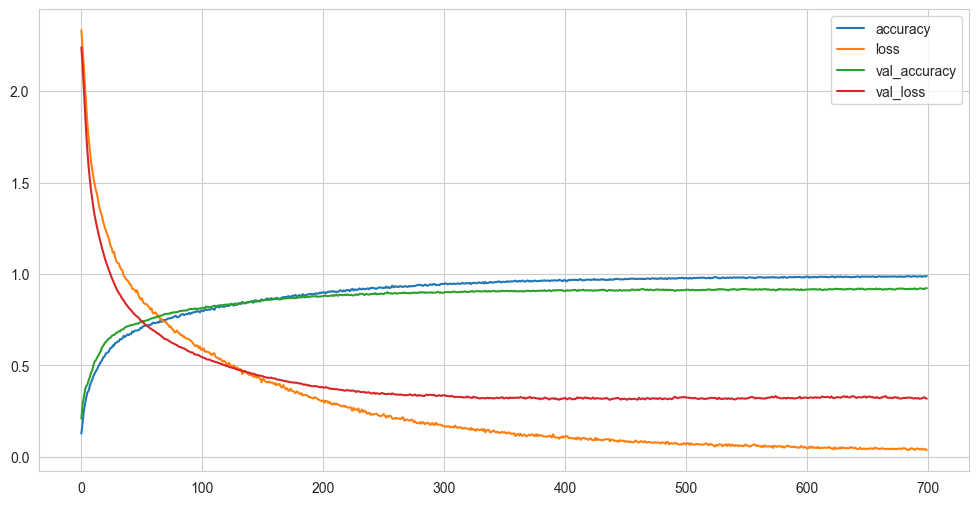

In [ ]:
plotHistory(model_3_history)

In [ ]:
test_loss, nn3 = model_3.evaluate(X_test, y_test, batch_size=128)
print("The test Loss is :",test_loss)
print("\nThe Best test Accuracy is :",nn3*100)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9200 - loss: 0.3181 
The test Loss is : 0.32363229990005493

The Best test Accuracy is : 91.65849089622498


In [17]:
model_4 = k.models.Sequential([
    k.layers.Dense(1024, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.Dropout(0.3),
    
    k.layers.Dense(512, activation='relu'),
    k.layers.Dropout(0.3),

    k.layers.Dense(256, activation='relu'),
    k.layers.Dropout(0.3),

    k.layers.Dense(128, activation='relu'),
    k.layers.Dropout(0.3),

    k.layers.Dense(64, activation='relu'),
    k.layers.Dropout(0.3),

    k.layers.Dense(10, activation='softmax'),
])
print(model_4.summary())
model_4_history = trainModel(model=model_4, X_train=X_train, y_train=y_train, 
                             X_dev=X_dev, y_dev=y_dev, epochs=500, optimizer='rmsprop')

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 1024)           │        59,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 757,322 (2.89 MB)

 Trainable params: 757,322 (2.89 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.2944 - loss: 1.9458 - val_accuracy: 0.5612 - val_loss: 1.2657
Epoch 2/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5276 - loss: 1.3609 - val_accuracy: 0.6820 - val_loss: 0.9353
Epoch 3/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6338 - loss: 1.1014 - val_accuracy: 0.7103 - val_loss: 0.8754
Epoch 4/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6797 - loss: 0.9652 - val_accuracy: 0.7457 - val_loss: 0.7370
Epoch 5/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.7309 - loss: 0.8278 - val_accuracy: 0.7720 - val_loss: 0.6868
Epoch 6/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7551 - loss: 0.7503 - val_accuracy: 0.7619 - val_loss: 0.7624
Epoch 7/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7759 - loss: 0.7160 - val_accuracy: 0.8225 - val_loss: 0.5611
Epoch 8/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8051 - loss: 0.6190 - val_accurac

KeyboardInterrupt: 

Max. Validation Accuracy 0.9398382306098938


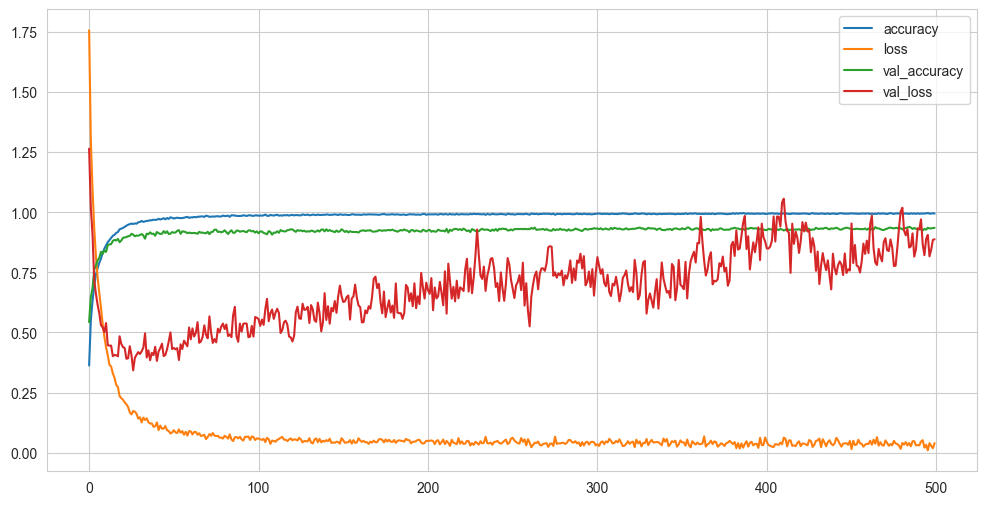

In [ ]:
plotHistory(model_4_history)

In [ ]:
test_loss, nn4 = model_4.evaluate(X_test, y_test, batch_size=128)
print("The test Loss is :",test_loss)
print("\nThe Best test Accuracy is :",nn4*100)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9448 - loss: 0.9099
The test Loss is : 1.056917428970337

The Best test Accuracy is : 93.52306127548218


In [ ]:
model_5 = k.models.Sequential([
    k.layers.Dense(1024, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.Dropout(0.3),
    
    k.layers.Dense(512, activation='relu'),
    k.layers.Dropout(0.3),

    k.layers.Dense(256, activation='relu'),
    k.layers.Dropout(0.3),

    k.layers.Dense(128, activation='relu'),
    k.layers.Dropout(0.3),

    k.layers.Dense(64, activation='relu'),
    k.layers.Dropout(0.3),
    
    k.layers.Dense(32, activation='relu'),
    k.layers.Dropout(0.3),
    

    k.layers.Dense(10, activation='softmax'),
])
print(model_5.summary())
model_5_history = trainModel(model=model_5, X_train=X_train, y_train=y_train, 
                             X_dev=X_dev, y_dev=y_dev, epochs=500, optimizer='rmsprop')

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_73 (Dense)                │ (None, 1024)           │        59,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 759,450 (2.90 MB)

 Trainable params: 759,450 (2.90 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.1535 - loss: 2.2516 - val_accuracy: 0.3716 - val_loss: 1.8929
Epoch 2/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.2853 - loss: 1.9599 - val_accuracy: 0.4247 - val_loss: 1.6569
Epoch 3/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.3466 - loss: 1.7944 - val_accuracy: 0.5056 - val_loss: 1.3930
Epoch 4/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.4129 - loss: 1.6412 - val_accuracy: 0.5753 - val_loss: 1.3216
Epoch 5/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.4678 - loss: 1.5355 - val_accuracy: 0.6213 - val_loss: 1.1766
Epoch 6/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5107 - loss: 1.4296 - val_accuracy: 0.6259 - val_loss: 1.1215
Epoch 7/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5411 - loss: 1.3293 - val_accuracy: 0.6507 - val_loss: 1.0244
Epoch 8/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.5752 - loss: 1.2325 - val_accurac

Max. Validation Accuracy 0.9413549304008484


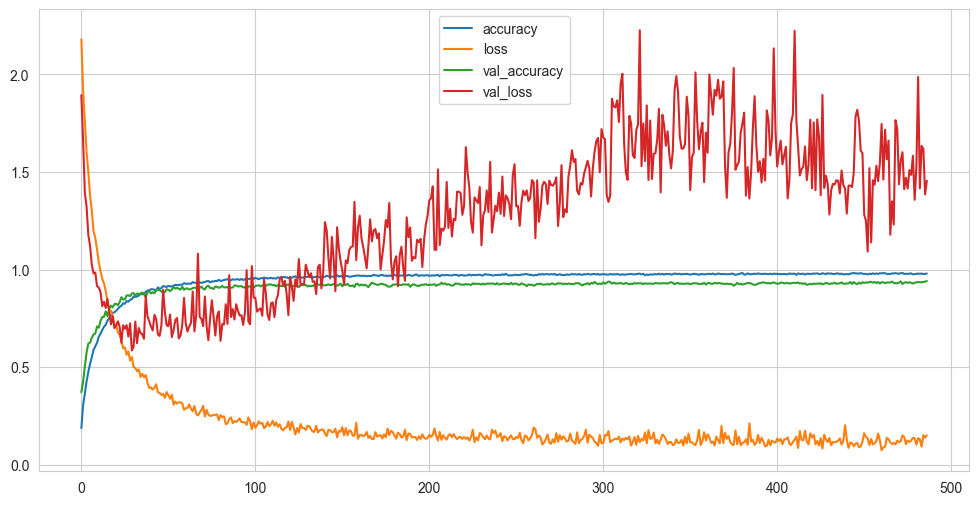

In [ ]:
plotHistory(model_5_history)

In [ ]:
test_loss, nn5 = model_4.evaluate(X_test, y_test, batch_size=128)
print("The test Loss is :",test_loss)
print("\nThe Best test Accuracy is :",nn5*100)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9448 - loss: 0.9099
The test Loss is : 1.056917428970337

The Best test Accuracy is : 93.52306127548218


modello 6 provo a mettere la batch normalization

In [13]:
model_6 = k.models.Sequential([
    k.layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.BatchNormalization(),
    k.layers.Dropout(0.2),
    k.layers.Dense(256, activation='relu'),
    k.layers.BatchNormalization(),
    k.layers.Dropout(0.2),
    k.layers.Dense(128, activation='relu'),
    k.layers.BatchNormalization(),
    k.layers.Dropout(0.2),
    k.layers.Dense(64, activation='relu'),
    k.layers.BatchNormalization(),
    k.layers.Dropout(0.2),
    k.layers.Dense(10, activation='softmax'),
])
print(model_6.summary())
model_6_history = trainModel(model=model_6, X_train=X_train, y_train=y_train, 
                             X_dev=X_dev, y_dev=y_dev, epochs=50, optimizer='rmsprop')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,666 (807.29 KB)

 Trainable params: 204,746 (799.79 KB)

 Non-trainable params: 1,920 (7.50 KB)

None
Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.4138 - loss: 1.8133 - val_accuracy: 0.6385 - val_loss: 1.4030
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6490 - loss: 1.0233 - val_accuracy: 0.7053 - val_loss: 1.0073
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7275 - loss: 0.8292 - val_accuracy: 0.7508 - val_loss: 0.7653
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7655 - loss: 0.7020 - val_accuracy: 0.7836 - val_loss: 0.6224
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7882 - loss: 0.6142 - val_accuracy: 0.8205 - val_loss: 0.5317
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8163 - loss: 0.5503 - val_accuracy: 0.8322 - val_loss: 0.4993
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8396 - loss: 0.4721 - val_accuracy: 0.8463 - val_loss: 0.4500
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8560 - loss: 0.4331 - val_accuracy: 0.849

Max. Validation Accuracy 0.9196157455444336


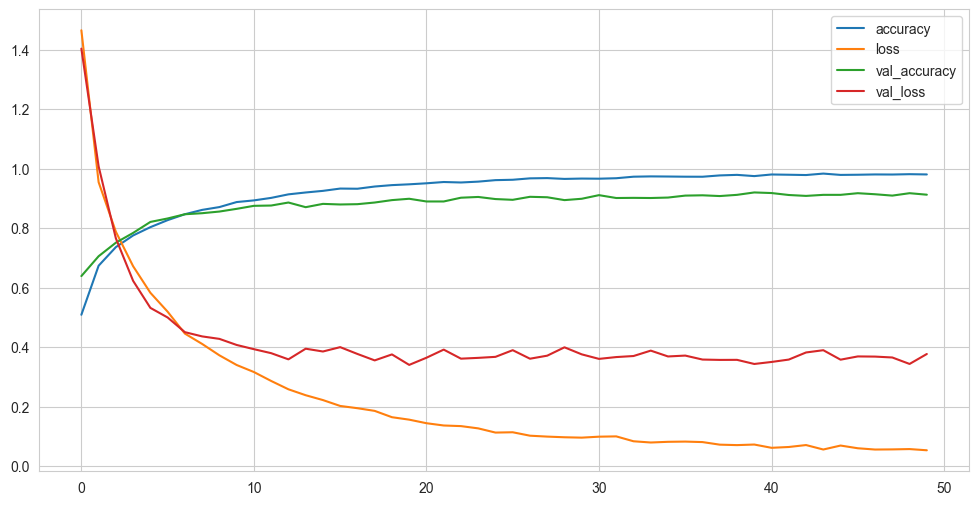

In [14]:
plotHistory(model_6_history)

In [ ]:
test_loss, nn6 = model_6.evaluate(X_test, y_test, batch_size=128)
print("The test Loss is :",test_loss)
print("\nThe Best test Accuracy is :",nn6 *100)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9188 - loss: 0.3733
The test Loss is : 0.37910741567611694

The Best test Accuracy is : 91.167813539505


modello 7 provo a usare nuovo ottimizzatore

In [16]:
model_7 = k.models.Sequential([
    k.layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.BatchNormalization(),
    k.layers.Dropout(0.2),
    k.layers.Dense(256, activation='relu'),
    k.layers.BatchNormalization(),
    k.layers.Dropout(0.2),
    k.layers.Dense(128, activation='relu'),
    k.layers.BatchNormalization(),
    k.layers.Dropout(0.2),
    k.layers.Dense(64, activation='relu'),
    k.layers.BatchNormalization(),
    k.layers.Dropout(0.2),
    k.layers.Dense(10, activation='softmax'),
])
print(model_7.summary())
model_7_history = trainModel(model=model_7, X_train=X_train, y_train=y_train, 
                             X_dev=X_dev, y_dev=y_dev, epochs=50, optimizer='adam')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 512)            │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,666 (807.29 KB)

 Trainable params: 204,746 (799.79 KB)

 Non-trainable params: 1,920 (7.50 KB)

None
Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.3488 - loss: 1.9908 - val_accuracy: 0.6112 - val_loss: 1.4184
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6331 - loss: 1.0754 - val_accuracy: 0.7108 - val_loss: 1.0559
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7036 - loss: 0.8569 - val_accuracy: 0.7548 - val_loss: 0.7884
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7403 - loss: 0.7525 - val_accuracy: 0.7836 - val_loss: 0.6452
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7831 - loss: 0.6398 - val_accuracy: 0.8180 - val_loss: 0.5425
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8032 - loss: 0.5698 - val_accuracy: 0.8286 - val_loss: 0.4872
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8316 - loss: 0.4961 - val_accuracy: 0.8448 - val_loss: 0.4614
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8441 - loss: 0.4537 - val_accuracy: 0.850

Max. Validation Accuracy 0.9145601391792297


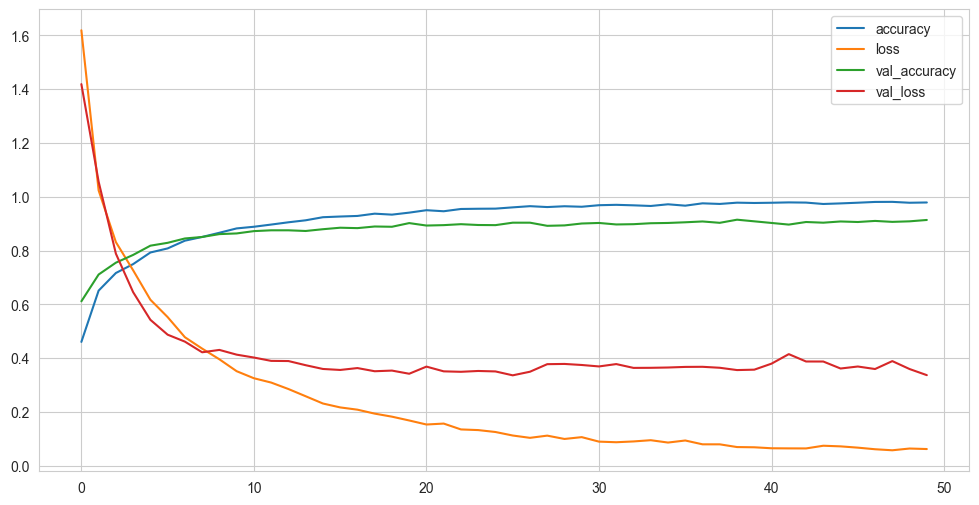

In [17]:
plotHistory(model_7_history)

In [ ]:
test_loss, nn7 = model_7.evaluate(X_test, y_test, batch_size=128)
print("The test Loss is :",test_loss)
print("\nThe Best test Accuracy is :", nn7 *100)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9167 - loss: 0.3544 
The test Loss is : 0.3666267693042755

The Best test Accuracy is : 91.26594662666321


modello 8, provo a lavorare sui dropout

In [ ]:
model_8 = k.models.Sequential([
    k.layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.Dropout(0.2),
    
    k.layers.Dense(256, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(128, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(64, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(10, activation='softmax'),
])
print(model_8.summary())
model_8_history = trainModel(model=model_8, X_train=X_train, y_train=y_train, 
                             X_dev=X_dev, y_dev=y_dev, epochs=100, optimizer='adam')

Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_187 (Dense)               │ (None, 512)            │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_151 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_188 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_152 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_189 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_153 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_190 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_154 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_191 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,826 (792.29 KB)

 Trainable params: 202,826 (792.29 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.3095 - loss: 1.9265 - val_accuracy: 0.5971 - val_loss: 1.1243
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5874 - loss: 1.1821 - val_accuracy: 0.6977 - val_loss: 0.8678
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6820 - loss: 0.9514 - val_accuracy: 0.7533 - val_loss: 0.7261
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7278 - loss: 0.8142 - val_accuracy: 0.7851 - val_loss: 0.6431
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7470 - loss: 0.7280 - val_accuracy: 0.7998 - val_loss: 0.5828
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7821 - loss: 0.6328 - val_accuracy: 0.8286 - val_loss: 0.5330
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8141 - loss: 0.5550 - val_accuracy: 0.8291 - val_loss: 0.5072
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8345 - loss: 0.5061 - val_accurac

Max. Validation Accuracy 0.9266936182975769


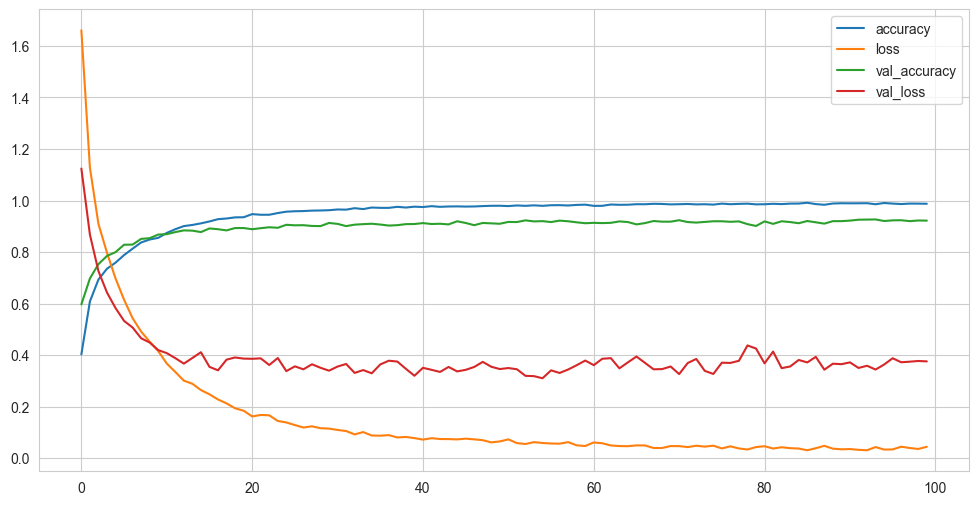

In [ ]:
plotHistory(model_8_history)

In [ ]:
test_loss, nn8 = model_8.evaluate(X_test, y_test, batch_size=128)
print("The test Loss is :",test_loss)
print("\nThe Best test Accuracy is :", nn8 *100)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9136 - loss: 0.4235
The test Loss is : 0.41326040029525757

The Best test Accuracy is : 91.95289611816406


modello 9: provo a cambiare le funzioni di attivazione. Ottimo con 100 epoche

In [19]:

model_9 = k.models.Sequential([
    k.layers.Dense(512, input_shape=(X_train.shape[1],)),
    k.layers.LeakyReLU(alpha=0.01),  # Aggiungi LeakyReLU
    k.layers.Dropout(0.4),

    k.layers.Dense(256),
    k.layers.LeakyReLU(alpha=0.01),  # Aggiungi LeakyReLU
    k.layers.Dropout(0.4),

    k.layers.Dense(128),
    k.layers.LeakyReLU(alpha=0.01),  # Aggiungi LeakyReLU
    k.layers.Dropout(0.4),

    k.layers.Dense(64),
    k.layers.LeakyReLU(alpha=0.01),  # Aggiungi LeakyReLU
    k.layers.Dropout(0.4),
    
    k.layers.Dense(32),
    k.layers.LeakyReLU(alpha=0.01),  # Aggiungi LeakyReLU
    k.layers.Dropout(0.4),

    k.layers.Dense(10, activation='softmax')
])

print(model_9.summary())

# Compilazione e training del modello
model_9.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_9_history = trainModel(model=model_9, X_train=X_train, y_train=y_train, 
                             X_dev=X_dev, y_dev=y_dev, epochs=100, optimizer='adam')


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 512)            │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,586 (799.16 KB)

 Trainable params: 204,586 (799.16 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.1225 - loss: 2.3380 - val_accuracy: 0.3746 - val_loss: 2.0277
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2553 - loss: 2.0619 - val_accuracy: 0.4378 - val_loss: 1.5886
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3471 - loss: 1.7671 - val_accuracy: 0.5046 - val_loss: 1.3682
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4208 - loss: 1.6130 - val_accuracy: 0.5627 - val_loss: 1.2658
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4669 - loss: 1.4923 - val_accuracy: 0.6087 - val_loss: 1.1733
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5065 - loss: 1.3966 - val_accuracy: 0.6325 - val_loss: 1.0832
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5426 - loss: 1.3046 - val_accuracy: 0.6754 - val_loss: 1.0183
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5790 - loss: 1.2313 - val_accuracy: 0.695

Max. Validation Accuracy 0.8200201988220215


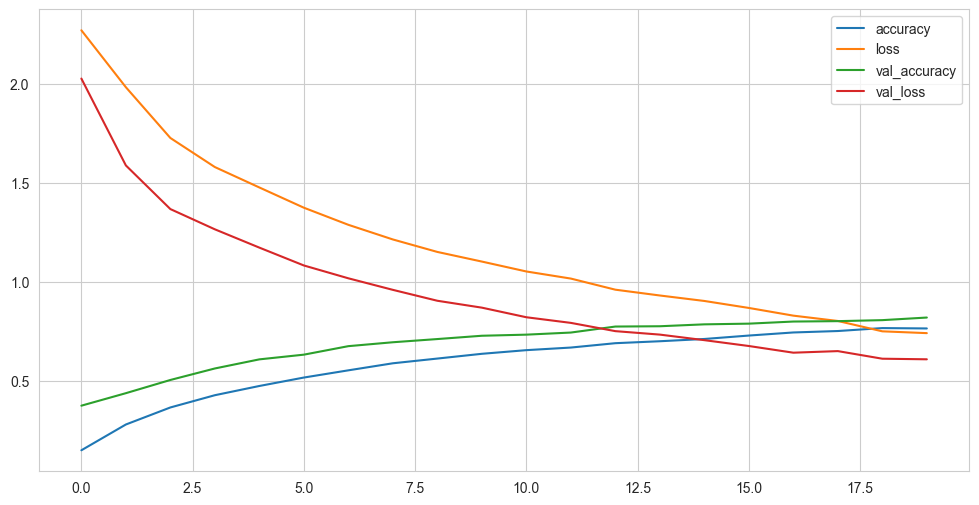

In [20]:
plotHistory(model_9_history)

In [ ]:
test_loss, nn9 = model_9.evaluate(X_test, y_test, batch_size=128)
print("The test Loss is :",test_loss)
print("\nThe Best test Accuracy is :", nn9*100)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8208 - loss: 0.5655
The test Loss is : 0.575994074344635

The Best test Accuracy is : 82.8262984752655


In [ ]:
model_10 = k.models.Sequential([
    k.layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.Dropout(0.6),
    
    k.layers.Dense(256, activation='relu'),
    k.layers.Dropout(0.6),

    k.layers.Dense(128, activation='relu'),
    k.layers.Dropout(0.6),

    k.layers.Dense(64, activation='relu'),
    k.layers.Dropout(0.6),

    k.layers.Dense(10, activation='softmax'),
])
print(model_10.summary())
model_10_history = trainModel(model=model_10, X_train=X_train, y_train=y_train, 
                             X_dev=X_dev, y_dev=y_dev, epochs=300, optimizer='adam')

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 512)            │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,826 (792.29 KB)

 Trainable params: 202,826 (792.29 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.1052 - loss: 2.6280 - val_accuracy: 0.2912 - val_loss: 2.2571
Epoch 2/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1603 - loss: 2.2552 - val_accuracy: 0.3271 - val_loss: 2.0421
Epoch 3/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2310 - loss: 2.0851 - val_accuracy: 0.3574 - val_loss: 1.7832
Epoch 4/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2964 - loss: 1.9200 - val_accuracy: 0.4055 - val_loss: 1.6563
Epoch 5/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3246 - loss: 1.8183 - val_accuracy: 0.4651 - val_loss: 1.5598
Epoch 6/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3680 - loss: 1.7208 - val_accuracy: 0.5101 - val_loss: 1.4678
Epoch 7/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3928 - loss: 1.6440 - val_accuracy: 0.5359 - val_loss: 1.3787
Epoch 8/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4216 - loss: 1.5714 - val_accurac

In [ ]:
test_loss, nn10 = model_10.evaluate(X_test, y_test, batch_size=128)
print("The test Loss is :",test_loss)
print("\nThe Best test Accuracy is :", nn10*100)




#####DEVO PROVARE CON 400 E 500 EPOCHEEEEEEEEEEE

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9141 - loss: 0.2677
The test Loss is : 0.3117350935935974

The Best test Accuracy is : 90.57899713516235


Max. Validation Accuracy 0.9251769185066223


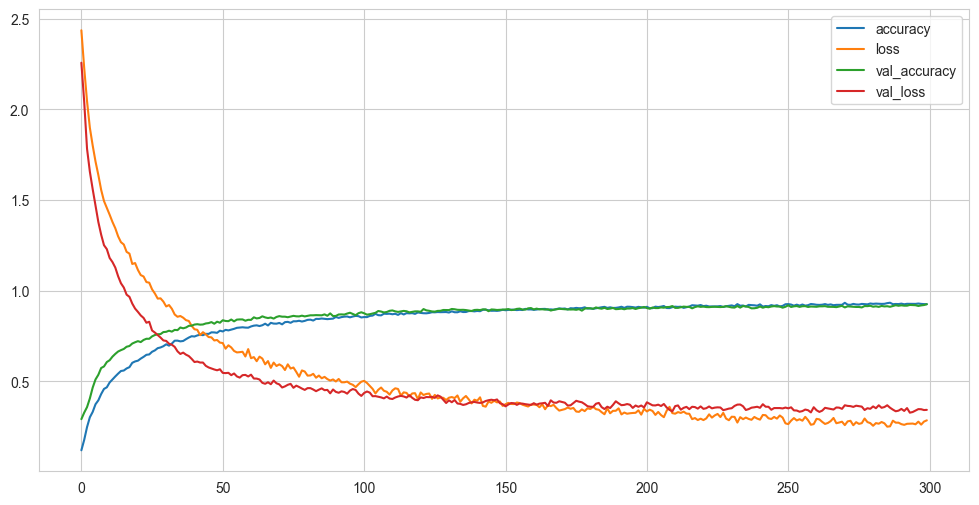

In [ ]:
plotHistory(model_10_history)

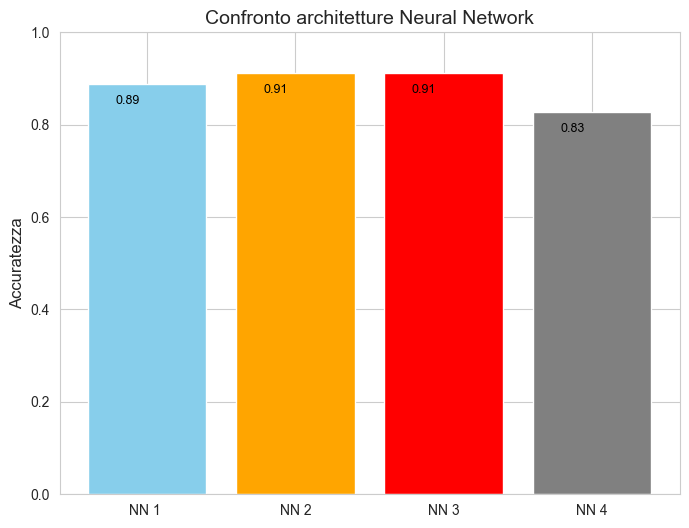

In [ ]:
Grafico_Confronto_NN(nn1, nn6, nn7, nn9)